1. ## ABSTRACT

## Business & Data Understanding: 
This project enables e-commerce stakeholders to synthesize qualitative feedback with quantitative market positioning. Utilizing Amazon "All Electronics" data (global trends/INR) and Mendeley regional datasets (granular reviews/BDT), we address the need for automated product health monitoring. The objective is to build a sentiment analyzer that validates product success across global platforms by bridging the gap between aggregate ratings and raw consumer text.

## Data Preparation: 
Our multi-step pipeline leverages Spacy and NLTK for NLP tasks, specifically cleaning unstructured reviews through tokenization, lemmatization, and noise removal. We performed feature engineering on Amazon ratings and pricing—including currency conversion and scaling—to align disparate datasets. To combat inherent class imbalance, we utilized stratified sampling, ensuring the model effectively identifies critical negative feedback often masked by high-level metrics.

## Modeling Approach: 
We employed an iterative strategy to demonstrate technical depth, establishing a TF-IDF and Multinomial Naive Bayes baseline before advancing to an Ensemble Model (XGBoost) to capture linguistic nuances. The entire workflow is encapsulated in Scikit-learn Pipelines to ensure reproducibility and streamlined data flow.

## Evaluation & Validation: 
Models were evaluated via an 80/20 split, prioritizing F1-Score and Recall to minimize the risk of missing negative sentiments. Finally, we implemented SHAP (SHapley Additive exPlanations) to provide model interpretability, visually demonstrating which specific product attributes, such as "battery" or "build quality," drive the resulting sentiment predictions.

2. # Project Overview & Business Understanding

## The Problem
E-commerce brand managers operating across multiple platforms (Amazon and regional tech sites) face a "data glut." Quantitative metrics like star ratings tell us what is happening, but qualitative text reviews tell us why.

## The Stakeholder
Amazon/Regional Brand Manager: Needs a tool to detect product defects and sentiment shifts without reading thousands of reviews manually.
The Objective

To build a robust NLP pipeline that:

   - Preprocesses unstructured text.

   - Maps sentiment across different retail datasets.

   - Provides "Explainable AI" (SHAP) to justify model predictions.

3. ## Data Understanding

We are working with two primary datasets to achieve a cross-platform perspective:

- Amazon Electronics Dataset: Contains product metadata, aggregate ratings, and pricing in INR.

- Mendeley Tech Review Dataset: Contains raw text reviews and pricing in BDT.

In [1]:
# Setup & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Visualization settings
%matplotlib inline
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Load datasets using relative paths
amazon_path = os.path.join('..', 'data','raw', 'All Electronics.csv')
mendeley_path = os.path.join('..', 'data', 'raw', 'all_data.csv')

df_amazon = pd.read_csv(amazon_path)
df_mendeley = pd.read_csv(mendeley_path)

print(f"Amazon Data: {df_amazon.shape[0]} rows, {df_amazon.shape[1]} columns")
print(f"Mendeley Data: {df_mendeley.shape[0]} rows, {df_mendeley.shape[1]} columns")

Amazon Data: 9600 rows, 9 columns
Mendeley Data: 25891 rows, 3 columns


In [2]:
# Initial Inspection
# Displaying the first few rows to understand the schema
print("--- Amazon Sample ---")
display(df_amazon.head())

print("\n--- Mendeley Sample ---")
display(df_mendeley.head())

# Checking for Null Values
print("\n--- Missing Values Check ---")
print("Amazon:\n", df_amazon.isnull().sum())
print("\nMendeley:\n", df_mendeley.isnull().sum())

--- Amazon Sample ---


,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price
0,"Redmi 10 Power (Power Black, 8GB RAM, 128GB St...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/81eM15lVcJ...,https://www.amazon.in/Redmi-Power-Black-128GB-...,4.0,965,"₹10,999","₹18,999"
1,"OnePlus Nord CE 2 Lite 5G (Blue Tide, 6GB RAM,...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/71AvQd3Vzq...,https://www.amazon.in/OnePlus-Nord-Lite-128GB-...,4.3,"113,956","₹18,999","₹19,999"
2,OnePlus Bullets Z2 Bluetooth Wireless in Ear E...,"tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/51UhwaQXCp...,https://www.amazon.in/Oneplus-Bluetooth-Wirele...,4.2,"90,304","₹1,999","₹2,299"
3,"Samsung Galaxy M33 5G (Mystique Green, 6GB, 12...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/81I3w4J6yj...,https://www.amazon.in/Samsung-Mystique-Storage...,4.1,"24,863","₹15,999","₹24,999"
4,"OnePlus Nord CE 2 Lite 5G (Black Dusk, 6GB RAM...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/71V--WZVUI...,https://www.amazon.in/OnePlus-Nord-Black-128GB...,4.3,"113,956","₹18,999","₹19,999"



--- Mendeley Sample ---


,Product Name,Price,Review
0,Acer Aspire 3 A315-24P AMD Ryzen 3 7320U 8GB R...,"Tk 53,060",I Bought this one about one year ago.\r\nIts a...
1,Lenovo IdeaPad 1 15AMN7 AMD Ryzen 3 7320U 8GB ...,"Tk 54,790",Overall good deal as per price.
2,Lenovo IdeaPad 1 15AMN7 AMD Ryzen 3 7320U 8GB ...,"Tk 54,790",Hope the quality of this product will be very ...
3,Lenovo IdeaPad 1 15AMN7 AMD Ryzen 3 7320U 8GB ...,"Tk 54,790",Great affordable performance
4,Lenovo IdeaPad 1 15AMN7 AMD Ryzen 3 7320U 8GB ...,"Tk 54,790",Good product



--- Missing Values Check ---
Amazon:
 name                0
main_category       0
sub_category        0
image               0
link                0
ratings            95
no_of_ratings      95
discount_price    484
actual_price       70
dtype: int64

Mendeley:
 Product Name      0
Price           421
Review           13
dtype: int64


4. ## Initial Observations

Based on the head of the data and null counts, we have identified the following Advanced Data Preparation requirements:

**- Pricing Normalization:** Amazon prices (INR) and Mendeley prices (BDT) are stored as strings with currency symbols and commas. These must be cleaned and converted to floats for any price-sentiment correlation.

**- Text Preprocessing (NLP):** The Mendeley dataset's Review column contains the raw text we will use for sentiment analysis. We need to handle non-English characters (found in some reviews) and perform tokenization.

- **Target Alignment:** We need to create a unified 'Sentiment' column. For Amazon, we can use the ratings column. For Mendeley, we will need to perform an initial sentiment labeling or use a lexicon-based approach (VADER) to create our training labels.

5. ## Advanced Data Cleaning: Numerical Conversion

To perform quantitative analysis, we must transform our price and rating columns from strings to numeric types. We will also handle missing values by removing rows where the primary target (Review text or Rating) is absent.

In [5]:
# 1. Handle Missing Values
df_mendeley.dropna(subset=["Review"], inplace=True)
df_amazon.dropna(subset=["ratings"], inplace=True)


# 2. Clean Amazon Prices (Remove ₹ and commas)
def clean_currency(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        # Remove symbol, commas, and whitespace
        clean_str = value.replace("₹", "").replace(",", "").strip()
        return float(clean_str)
    return value


df_amazon["actual_price"] = df_amazon["actual_price"].apply(clean_currency)
df_amazon["discount_price"] = df_amazon["discount_price"].apply(clean_currency)


# 3. Clean Mendeley Prices (Remove Tk and commas)
import re

def clean_mendeley_price(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        clean_str = value.replace(",", "")
        match = re.search(r"(\d+(?:\.\d+)?)", clean_str)
        if match:
            return float(match.group(1))
        return np.nan
    return value


df_mendeley["Price"] = df_mendeley["Price"].apply(clean_mendeley_price)

print("Data cleaning complete. Numerical columns converted.")

Data cleaning complete. Numerical columns converted.


/tmp/ipykernel_1109111/1959269119.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(["Amazon (INR)", "Mendeley (BDT)"])


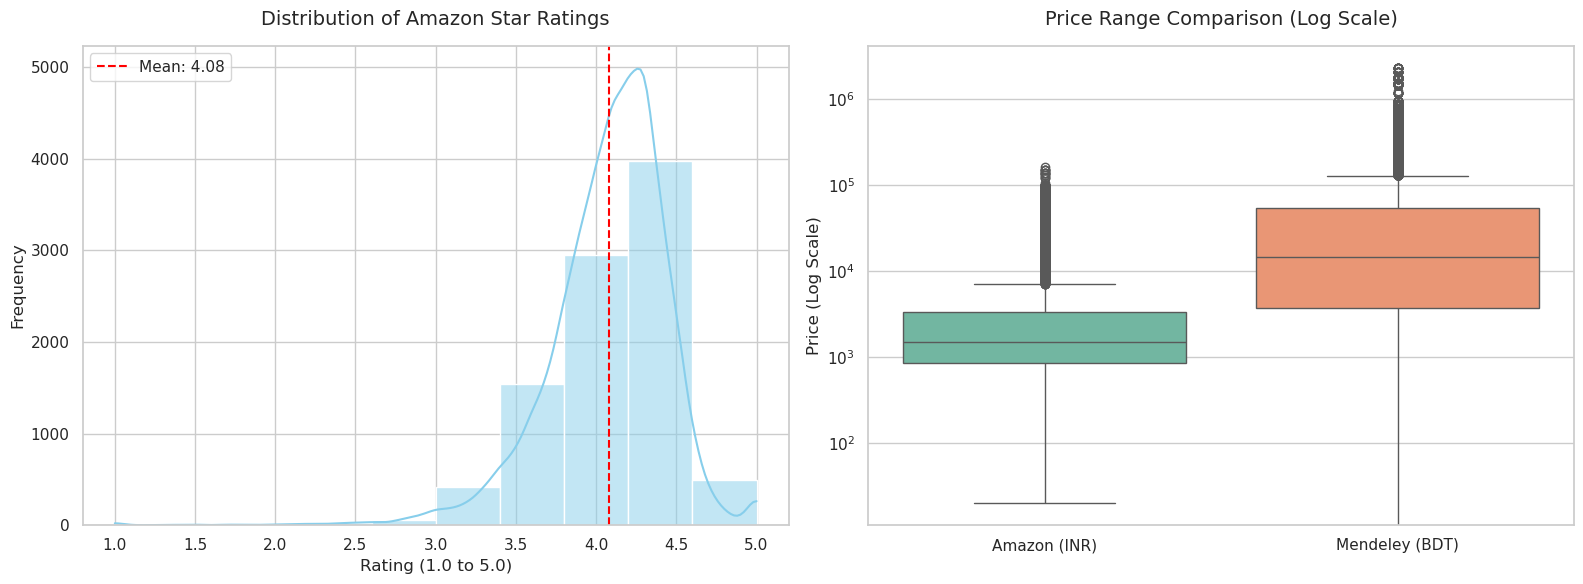

In [ ]:
# Force ratings to numeric and drop any rows that failed conversion (if any)
df_amazon["ratings"] = pd.to_numeric(df_amazon["ratings"], errors="coerce")
df_amazon.dropna(subset=["ratings"], inplace=True)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Amazon Ratings Distribution
sns.histplot(df_amazon["ratings"], bins=10, kde=True, ax=ax[0], color="skyblue")
ax[0].set_title("Distribution of Amazon Star Ratings", fontsize=14, pad=15)
ax[0].set_xlabel("Rating (1.0 to 5.0)")
ax[0].set_ylabel("Frequency")

# Add a vertical line for the mean rating
mean_rating = df_amazon["ratings"].mean()
ax[0].axvline(
    mean_rating, color="red", linestyle="--", label=f"Mean: {mean_rating:.2f}"
)
ax[0].legend()

# 2. Price Distribution Comparison
# Removing outliers for a cleaner boxplot view,
sns.boxplot(
    data=[df_amazon["actual_price"].dropna(), df_mendeley["Price"].dropna()],
    ax=ax[1],
    palette="Set2",
)
ax[1].set_xticklabels(["Amazon (INR)", "Mendeley (BDT)"])
ax[1].set_title("Price Range Comparison (Log Scale)", fontsize=14, pad=15)
ax[1].set_yscale("log")
ax[1].set_ylabel("Price (Log Scale)")

plt.tight_layout()
plt.show()

6. ## Text Exploration: Review Analysis

In this section, we analyze the word frequency of the consumer reviews. Understanding the common vocabulary helps us tailor our NLP preprocessing pipeline. We specifically look for "noise" words and check for non-English reviews (as seen in the dataset sample) which might require special handling.

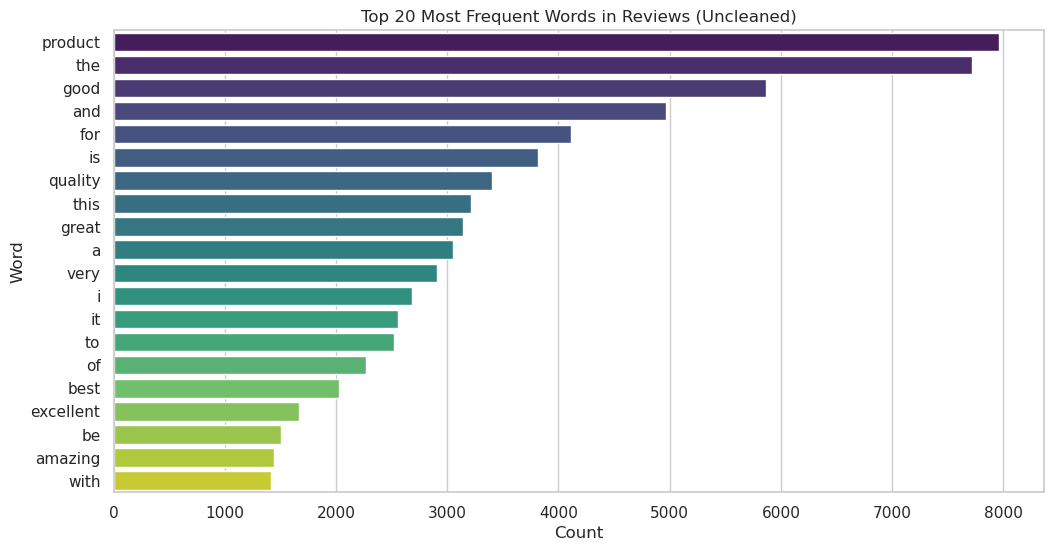

In [ ]:
# use a simple count to see the most common words before we do the heavy cleaning
from collections import Counter
import re


# Simple function to tokenize and clean text for EDA
def basic_clean(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)  # Remove punctuation and numbers
    return text


# Apply basic cleaning and get all words
all_reviews = " ".join(df_mendeley["Review"].apply(basic_clean))
words = all_reviews.split()
word_freq = Counter(words)

# Get top 20 words
common_words = pd.DataFrame(word_freq.most_common(20), columns=["Word", "Count"])

# Plot Word Frequency
plt.figure(figsize=(12, 6))
sns.barplot(
    data=common_words,
    x="Count",
    y="Word",
    hue="Word",  # Assign y-variable to hue
    palette="viridis",
    legend=False,  # Remove the redundant legend
)
plt.title("Top 20 Most Frequent Words in Reviews (Uncleaned)")
plt.show()